# 01 - Data Download and Annotation

This notebook records how the dataset was built. The heavy steps
(download and annotation) were run from the terminal as scripts in `scripts/`
and are documented here rather than re-run.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.home() / "amr-project"
PROC = ROOT / "data" / "processed"
AMR_DIR = ROOT / "data" / "amr"

sns.set_theme(style="whitegrid")
print("project folder:", ROOT)


project folder: /home/homepcmike_ambasa_k1/amr-project


In [4]:
labels = pd.read_csv(PROC / "labels_wide.csv", index_col=0, dtype={"genome_id": str})
complete = [l.strip() for l in open(PROC / "list_complete.txt")]
labels = labels.loc[labels.index.isin(complete)]

print(len(labels), "genomes with labels for all three drugs")
print(len(list(AMR_DIR.glob("*.tsv"))), "annotation files in data/amr")
labels.head()

2440 genomes with labels for all three drugs
2440 annotation files in data/amr


,ceftriaxone,ciprofloxacin,gentamicin
genome_id,,,
573.12771,1.0,0.0,0.0
573.12772,1.0,1.0,1.0
573.12773,1.0,1.0,1.0
573.12777,1.0,1.0,1.0
573.12778,1.0,1.0,1.0


               Susceptible  Resistant
ceftriaxone            415       2025
ciprofloxacin          577       1863
gentamicin            1426       1014


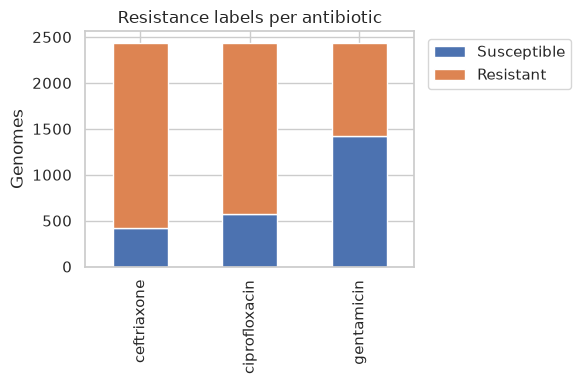

In [6]:
summary = (labels.apply(lambda s: s.value_counts())
                 .rename(index={0.0: "Susceptible", 1.0: "Resistant"}).T)
print(summary)

summary.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.ylabel("Genomes")
plt.title("Resistance labels per antibiotic")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## Class balance

Gentamicin is reasonably balanced (58% susceptible). Ciprofloxacin (24% susceptible)
and ceftriaxone (17% susceptible) are imbalanced, but every class has more than 400
genomes. Modelling will use stratified cross-validation, class weights, and metrics
such as ROC-AUC and balanced accuracy, because plain accuracy would be misleading.

## How the data was built

**Data source.** I first explored the NCBI Pathogen Detection Isolates Browser,
but per-drug counts were too small (for example, gentamicin had only 22 results).
I switched to BV-BRC, which has far more lab-measured resistance results.

**Selecting genomes and labels.**
- 8,436 *K. pneumoniae* genomes have AMR records in BV-BRC
- Kept records with a Resistant or Susceptible call and a documented lab method
- Drugs: ciprofloxacin, ceftriaxone, gentamicin
- Final set: 2,440 genomes labelled for all three drugs
- Script: `scripts/build_dataset.py`

**Genome download.** Genomes were downloaded with a resumable script
(`scripts/download_genomes.sh`). 26 downloads failed the first time and all
were recovered on a second pass.

**Annotation.** AMRFinderPlus 4.2.7 (database 2026-08-07.1) with
`--organism Klebsiella_pneumoniae --plus`, one output file per genome in
`data/amr/`. Script: `scripts/run_amrfinder.sh`